<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/InnovaRealEstate_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SISTEMA DE TASACIÓN INTELIGENTE — InnovaReal Estate**

---
# Fase I: Comprensión y Preparación de Datos

## 1. Importación de librerías

In [7]:
# Declaración de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 2. Carga y limpieza de datos

In [8]:
df = pd.read_csv('house-prices.csv').drop('Home', axis=1)

print("=== Vista previa del dataset ===")
print(df.head())
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

=== Vista previa del dataset ===
    Price  SqFt  Bedrooms  Bathrooms  Offers Brick Neighborhood
0  114300  1790         2          2       2    No         East
1  114200  2030         4          2       3    No         East
2  114800  1740         3          2       1    No         East
3   94700  1980         3          2       3    No         East
4  119800  2130         3          3       3    No         East

Dimensiones: 128 filas × 7 columnas


## 3. Verificación de valores nulos

In [9]:
print("=== Valores nulos por columna ===")
print(df.isnull().sum())

print("\n=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Estadísticas descriptivas ===")
print(df.describe())

=== Valores nulos por columna ===
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64

=== Tipos de datos ===
Price            int64
SqFt             int64
Bedrooms         int64
Bathrooms        int64
Offers           int64
Brick           object
Neighborhood    object
dtype: object

=== Estadísticas descriptivas ===
               Price         SqFt    Bedrooms   Bathrooms      Offers
count     128.000000   128.000000  128.000000  128.000000  128.000000
mean   130427.343750  2000.937500    3.023438    2.445312    2.578125
std     26868.770371   211.572431    0.725951    0.514492    1.069324
min     69100.000000  1450.000000    2.000000    2.000000    1.000000
25%    111325.000000  1880.000000    3.000000    2.000000    2.000000
50%    125950.000000  2000.000000    3.000000    2.000000    3.000000
75%    148250.000000  2140.000000    3.000000    3.000000    3.000000
max    211200.000000  2590.000000

## 4. Exploración Visual (EDA)

### 4.1 Heatmap de correlación

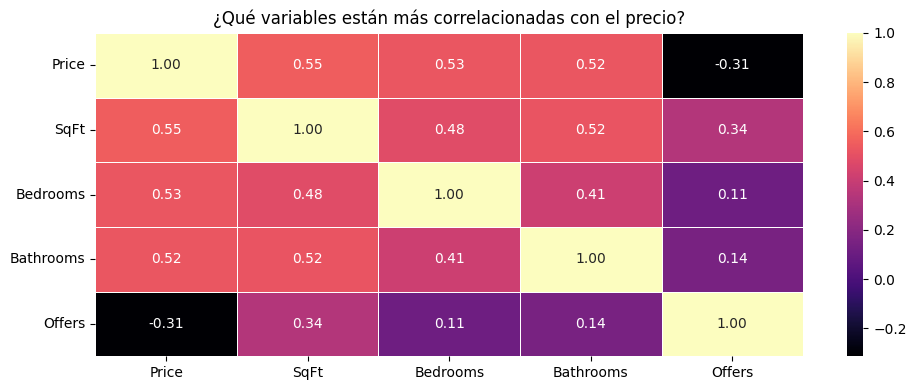

In [10]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='magma',
    fmt='.2f',
    linewidths=0.5
)
plt.title("¿Qué variables están más correlacionadas con el precio?")
plt.tight_layout()
plt.show()

Las 3 variables con mayor correlación con el precio son SqFt (0.55), Bedrooms (0.53) y Bathrooms (0.52). Las tres tienen valores muy similares, aunque la superficie es levemente la más influyente. Offers es la única con correlación negativa (-0.31), lo que se analiza más adelante.

### 4.2 Boxplot de Precio por Barrio

/tmp/ipykernel_9917/151127114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


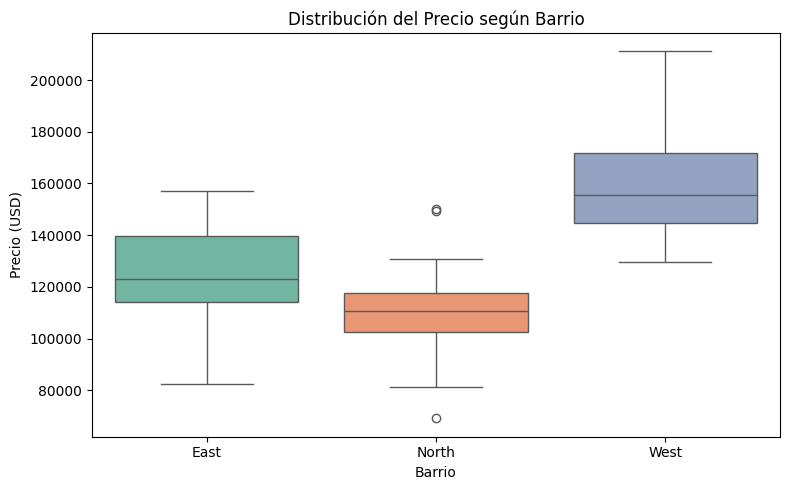

=== Precio mediano por barrio ===
Neighborhood
West     155400.0
East     123100.0
North    110750.0
Name: Price, dtype: float64


In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Neighborhood',
    y='Price',
    palette='Set2',
    order=['East', 'North', 'West']
)
plt.title("Distribución del Precio según Barrio")
plt.xlabel("Barrio")
plt.ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

# Calculamos la mediana de precio por barrio
print("=== Precio mediano por barrio ===")
print(df.groupby('Neighborhood')['Price'].median().sort_values(ascending=False))

El barrio West tiene las casas más caras, con una mediana de 155,400 USD, bastante por encima de East (123,100) y North (110,750). También es el barrio con más variación en precios, lo que muestra que hay propiedades de distintos rangos dentro del mismo sector.

### 4.3 Scatter Plot: Superficie vs Precio por Material

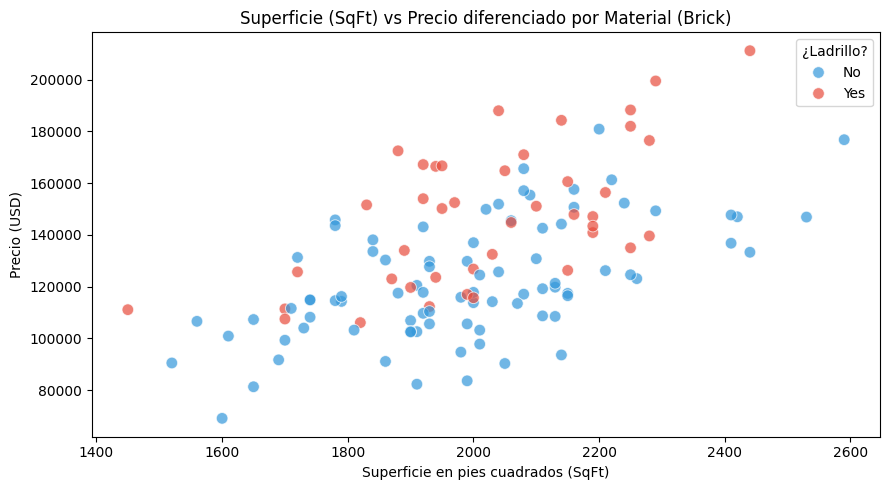

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='SqFt',
    y='Price',
    hue='Brick',
    palette={'Yes': '#e74c3c', 'No': '#3498db'},
    alpha=0.7,    # Transparencia para visualizar puntos superpuestos
    s=70
)
plt.title("Superficie (SqFt) vs Precio diferenciado por Material (Brick)")
plt.xlabel("Superficie en pies cuadrados (SqFt)")
plt.ylabel("Precio (USD)")
plt.legend(title="¿Ladrillo?")
plt.tight_layout()
plt.show()

Aquí see observa una tendencia positiva clara: a mayor superficie, mayor precio. Las casas de ladrillo (`Brick=Yes`) aparecen consistentemente en la parte superior del gráfico, confirmando que este material agrega valor significativo al precio de venta. Esta relación se cuantificará en los coeficientes del modelo.

---
# Fase II: Ingeniería de Datos

## 5. Encoding — One-Hot Encoding a variables categóricas

Qué es una Variable Ficticia (Dummy)?
Los modelos no entienden texto, solo números. Entonces variables como Brick (Yes/No) o Neighborhood (East/North/West) hay que convertirlas en columnas de 0 y 1. Si la casa es de ladrillo, Brick_Yes vale 1, si no, vale 0.



¿Por qué drop_first=True?
Si Neighborhood tiene 3 opciones, con 2 columnas es suficiente: si Neighborhood_North=0 y Neighborhood_West=0, ya sabemos que es East. Si dejamos las 3, una sobra y eso confunde al modelo porque puede calcular una a partir de las otras dos.

In [13]:
df_prep = pd.get_dummies(df, columns=['Brick', 'Neighborhood'], drop_first=True)

X = df_prep.drop('Price', axis=1)   # Variables predictoras (todo menos el precio)
y = df_prep['Price']                 # Variable objetivo: el precio que queremos predecir

print("=== Columnas del dataset preparado ===")
print(df_prep.columns.tolist())
print(f"\nDimensiones finales: {df_prep.shape}")
print("\n=== Vista previa ===")
print(df_prep.head())

=== Columnas del dataset preparado ===
['Price', 'SqFt', 'Bedrooms', 'Bathrooms', 'Offers', 'Brick_Yes', 'Neighborhood_North', 'Neighborhood_West']

Dimensiones finales: (128, 8)

=== Vista previa ===
    Price  SqFt  Bedrooms  Bathrooms  Offers  Brick_Yes  Neighborhood_North  \
0  114300  1790         2          2       2      False               False   
1  114200  2030         4          2       3      False               False   
2  114800  1740         3          2       1      False               False   
3   94700  1980         3          2       3      False               False   
4  119800  2130         3          3       3      False               False   

   Neighborhood_West  
0              False  
1              False  
2              False  
3              False  
4              False  


## 6. División Entrenamiento / Prueba (80% / 20%)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño conjunto prueba:        {X_test.shape[0]} registros")

Tamaño conjunto entrenamiento: 102 registros
Tamaño conjunto prueba:        26 registros


## 7. Escalado con StandardScaler

¿Por qué escalar?
SqFt maneja valores como 2,000 y Bedrooms valores entre 2 y 5. Si no escalamos, el modelo va a pensar que SqFt es más importante solo porque su número es más grande, cuando no necesariamente es así. El StandardScaler los pone a todos en la misma escala para que el modelo los compare de forma justa.

Importante: el escalador aprende los valores del conjunto de entrenamiento solamente. Al conjunto de prueba solo se le aplica esa misma transformación, sin que el modelo "vea" esos datos antes de evaluarse.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)       # Solo transforma con los parámetros ya aprendidos

print("✅ Escalado aplicado correctamente.")
print(f"\nMedia aproximada de X_train escalado (debe ser ≈ 0):")
print(X_train_scaled.mean(axis=0).round(4))
print(f"\nDesviación estándar de X_train escalado (debe ser ≈ 1):")
print(X_train_scaled.std(axis=0).round(4))

✅ Escalado aplicado correctamente.

Media aproximada de X_train escalado (debe ser ≈ 0):
[-0.  0. -0. -0.  0.  0.  0.]

Desviación estándar de X_train escalado (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1.]


---
# Fase III: Modelado y Evaluación

## 8. Entrenamiento del Modelo — Regresión Lineal Múltiple

In [16]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)   # Entrenamiento con los datos escalados

y_pred = model.predict(X_test_scaled)

print("Modelo entrenado correctamente.")
print(f"\nIntercepto (β₀): ${model.intercept_:,.2f}")

Modelo entrenado correctamente.

Intercepto (β₀): $130,747.06


## 9. Análisis de coeficientes — Ranking de Valorización

In [17]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Impacto_USD': model.coef_
}).sort_values(by='Impacto_USD', ascending=False)

print("RANKING DE VALORIZACIÓN:")
print(coef_df.to_string(index=False))

RANKING DE VALORIZACIÓN:
          Variable  Impacto_USD
              SqFt 12163.184747
 Neighborhood_West 10159.125316
         Brick_Yes  7646.503514
         Bathrooms  3613.944676
          Bedrooms  2676.640111
Neighborhood_North   710.367272
            Offers -9531.331691


## 10. Métricas de Evaluación

In [18]:
# (MAE)
mae = mean_absolute_error(y_test, y_pred)

# (MSE)
mse = mean_squared_error(y_test, y_pred)

# (R2)
r2 = r2_score(y_test, y_pred)

#(RMSE) - Muy común en el negocio
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: 8901.29
MSE: 114170418.45
RMSE: 10685.06
R2 Score: 0.8063


# Análisis de los resultados:




* R² Score = 0.8063: El modelo explica el 80.6% de la variación en los precios. Para ser un modelo básico con pocas variables, es un buen resultado.

* El 19% restante probablemente se explica por cosas que no están en el dataset, como el estado de la casa o el año de construcción.

* MAE = $8,901: En promedio el modelo se equivoca por esa cantidad.

  Sobre precios que van de $69,100 a  211,200, es un error razonable.


* RMSE = $10,685: Es más alto que el MAE, lo que significa que en algunos casos puntuales el error es bastante grande. Hay propiedades que el modelo no logra predecir bien con solo estas variables.

## 11. Visualización: Predicciones vs. Valores Reales

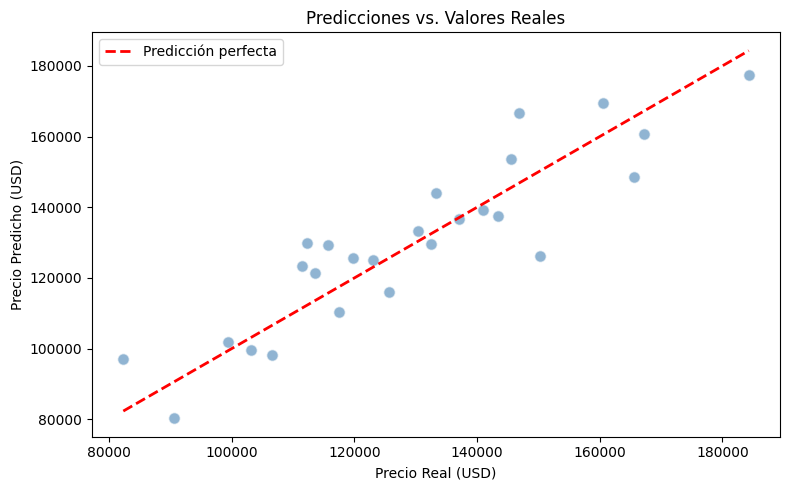

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=70)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Predicción perfecta'
)
plt.xlabel("Precio Real (USD)")
plt.ylabel("Precio Predicho (USD)")
plt.title("Predicciones vs. Valores Reales")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Visualización: Gráfico de Residuos

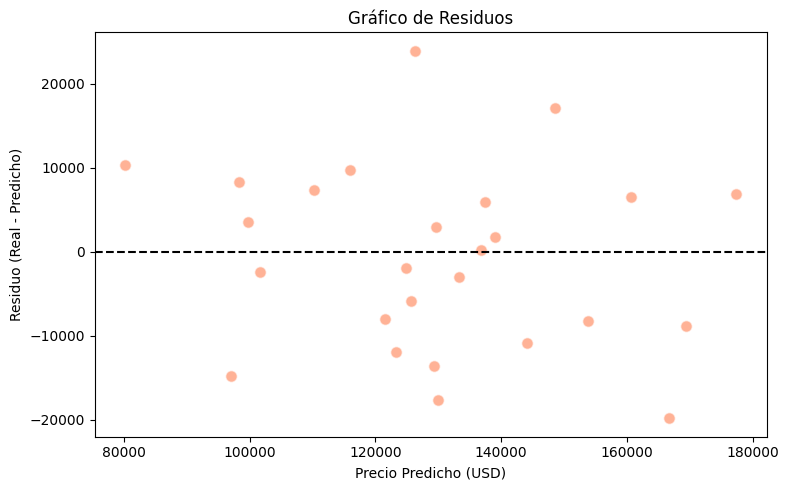

Media de residuos (debe ser ≈ 0): -873.87
Desviación estándar de residuos: 10,860.16


In [20]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, alpha=0.6, color='coral', edgecolors='white', s=70)
plt.axhline(y=0, color='black', linestyle='--', lw=1.5)
plt.xlabel("Precio Predicho (USD)")
plt.ylabel("Residuo (Real - Predicho)")
plt.title("Gráfico de Residuos")
plt.tight_layout()
plt.show()

print(f"Media de residuos (debe ser ≈ 0): {residuos.mean():,.2f}")
print(f"Desviación estándar de residuos: {residuos.std():,.2f}")

---
# 3. Preguntas de Análisis Crítico

*  Pregunta 1 — Si una casa suma un dormitorio pero mantiene los mismos metros cuadrados, ¿el precio sube o baja?
El coeficiente de Bedrooms es positivo, entonces técnicamente sube. Pero si los metros cuadrados no cambian, agregar un dormitorio significa que cada pieza queda más chica. El modelo igual lo refleja bien: el impacto de Bedrooms es mucho menor que el de SqFt, porque al final lo que más le importa al comprador es el espacio total, no cuántas piezas tiene.


*  Pregunta 2 — ¿Cuánto vale estar en West en vez de East?
Como East es la categoría base del modelo, el coeficiente de Neighborhood_West indica directo cuánto más vale una casa por estar ahí. Según el modelo, esa diferencia es de $10,159 USD, asumiendo que todo lo demás es igual.


*  Pregunta 3 — ¿El coeficiente negativo de Offers significa que las ofertas bajan el precio?
No. Lo que pasa es al revés: las casas con precio más bajo o más conveniente son las que reciben más ofertas. El modelo detecta esa correlación, pero no significa que las ofertas sean el problema. Es el precio el que atrae las ofertas, no al revés.


*  Pregunta 4 — ¿Los residuos se distribuyen de forma aleatoria o hay un patrón?
Los residuos se distribuyen de forma bastante aleatoria alrededor de cero, lo que es buena señal. No se ve un patrón claro de embudo ni de arco, por lo que el modelo cumple los supuestos básicos de la regresión lineal.


* Pregunta 5 — ¿Qué tipo de casa debería captar la inmobiliaria?
Mirando los coeficientes, el perfil que asegura el precio más alto es una casa grande (más de 2,000 SqFt), construida en ladrillo y ubicada en el barrio West. Esas tres características son las que más suman al precio según el modelo.

# Conclusiones Finales

El modelo logró un R² de 0.8063, lo que significa que explica el 80% de la variación en los precios, un resultado bastante bueno para un modelo inicial. Las variables que más influyen en el precio son la superficie, el barrio West y el material ladrillo.
El único coeficiente negativo relevante es el de Offers, pero como se explicó antes, no es que las ofertas bajen el valor, sino que las casas más baratas son las que generan más interés.
Como mejora futura se podría probar con modelos más complejos como Random Forest para reducir los errores en propiedades atípicas.